# DATA 620 Project 2: Two-Mode Network Analysis Using the MovieLens 100K Dataset

**Course:** DATA 620 Web Analytics\
**Project:** Project 2\
**Instructor:** Professor Alain Ledon

**Group Members:**

* Crystal Quezada
* Nana Kwasi Danquah
* Muhammad Suffyan Khan

## Project Objective

The purpose of this project is to identify and analyze a large two-mode network dataset. A two-mode network contains ties between two distinct groups, rather than ties within the same group.

For this project, we use the MovieLens 100K dataset. The two distinct groups are users and movies. A tie exists when a user rates a movie. The rating value is used as the edge weight in the network.

The project reduces the size of the network using an island-method style approach, where weaker ties are removed and stronger relationships are retained. After reducing the network, we analyze what the remaining structure reveals about both users and movies.


## Research Question

The main research question for this project is:

**How can an island-method reduction of a two-mode user–movie rating network reveal stronger preference-based clusters among users and movies?**

This question is appropriate for a two-mode network because the raw network contains two different types of nodes: users and movies. Users are connected to movies through rating behavior, but users are not directly connected to other users, and movies are not directly connected to other movies in the original dataset.

The analysis focuses on identifying stronger ties in the network by keeping higher ratings and removing weaker or less meaningful connections. After reducing the network, we examine what the remaining structure reveals about both distinct groups.

## Dataset Description

This project uses the MovieLens 100K dataset. The dataset contains user ratings of movies and is commonly used for recommendation-system and network-analysis examples. In this project, the dataset is modeled as a two-mode network.

The two node groups are:

* **Users:** individuals who rated movies
* **Movies:** films that received ratings from users

A tie exists when a user rates a movie. The rating value is used as an edge weight. Higher ratings represent stronger preference ties between users and movies.

The dataset is useful for this project because it contains a large number of user–movie ties and also includes additional information about both groups. User records include demographic fields such as age, gender, and occupation. Movie records include titles and genre indicators. These fields allow us to make meaningful inferences about both users and movies after reducing the network.


## 1. Load and Setup  

In [1]:
# Import required libraries

import os
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from networkx.algorithms import bipartite

# Global visualization settings

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

main_color = "#4C78A8"
accent_color = "#F58518"
green_color = "#54A24B"
red_color = "#E45756"
purple_color = "#B279A2"
gray_color = "#BAB0AC"

palette = [
    "#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2",
    "#B279A2", "#FF9DA6", "#9D755D", "#BAB0AC", "#59A14F"
]

## 2. Load Dataset Files

In this section, we load the three main MovieLens 100K files needed for this project.

The ratings file contains the ties between users and movies. The user file contains demographic information about users. The movie file contains movie titles and genre indicators.

These files allow us to build a two-mode network where users and movies are separate node groups, and ratings represent edges between them.


In [2]:
# Set dataset path
data_path = "data/ml-100k/"
# Check files in dataset folder
os.listdir(data_path)

['allbut.pl',
 'mku.sh',
 'README',
 'u.data',
 'u.genre',
 'u.info',
 'u.item',
 'u.occupation',
 'u.user',
 'u1.base',
 'u1.test',
 'u2.base',
 'u2.test',
 'u3.base',
 'u3.test',
 'u4.base',
 'u4.test',
 'u5.base',
 'u5.test',
 'ua.base',
 'ua.test',
 'ub.base',
 'ub.test']

### 2.1. Load Ratings 

In [3]:
# Load ratings data
# u.data columns: user_id, movie_id, rating, timestamp
ratings_cols = ["user_id", "movie_id", "rating", "timestamp"]

ratings = pd.read_csv(
    data_path + "u.data",
    sep="\t",
    names=ratings_cols
)

ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


### 2.2. Load Users

In [4]:
# Load user data
# u.user columns: user_id, age, gender, occupation, zip_code

user_cols = ["user_id", "age", "gender", "occupation", "zip_code"]

users = pd.read_csv(
    data_path + "u.user",
    sep="|",
    names=user_cols
)

users.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


### 2.3. Load Movies

In [5]:
# Load movie data
# u.item contains movie information and genre indicator columns

genre_cols = [
    "unknown", "Action", "Adventure", "Animation", "Children", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"
]

movie_cols = [
    "movie_id", "title", "release_date", "video_release_date", "imdb_url"
] + genre_cols

movies = pd.read_csv(
    data_path + "u.item",
    sep="|",
    names=movie_cols,
    encoding="latin-1"
)

movies.head()

,movie_id,title,release_date,video_release_date,imdb_url,unknown,Action,Adventure,Animation,Children,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


## 3. Initial Dataset Exploration

Before building the network, we first examine the basic structure of the MovieLens 100K dataset. This helps confirm that the dataset is large enough for the project and that it contains the two distinct groups required for a two-mode network.

The ratings table is the most important file for the network because each row represents a tie between a user and a movie. The users table gives information about the user group, and the movies table gives information about the movie group.


In [6]:
# Basic dataset counts

num_ratings = ratings.shape[0]
num_users = ratings["user_id"].nunique()
num_movies = ratings["movie_id"].nunique()

print("Number of ratings:", num_ratings)
print("Number of unique users:", num_users)
print("Number of unique movies:", num_movies)
print("Rating scale:", ratings["rating"].min(), "to", ratings["rating"].max())

Number of ratings: 100000
Number of unique users: 943
Number of unique movies: 1682
Rating scale: 1 to 5


### 3.1. Missing Value Check

In [7]:
# Check missing values in each dataset

print("Missing values in ratings data:")
print(ratings.isnull().sum())

print("\nMissing values in users data:")
print(users.isnull().sum())

print("\nMissing values in movies data:")
print(movies.isnull().sum())

Missing values in ratings data:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Missing values in users data:
user_id       0
age           0
gender        0
occupation    0
zip_code      0
dtype: int64

Missing values in movies data:
movie_id                 0
title                    0
release_date             1
video_release_date    1682
imdb_url                 3
unknown                  0
Action                   0
Adventure                0
Animation                0
Children                 0
Comedy                   0
Crime                    0
Documentary              0
Drama                    0
Fantasy                  0
Film-Noir                0
Horror                   0
Musical                  0
Mystery                  0
Romance                  0
Sci-Fi                   0
Thriller                 0
War                      0
Western                  0
dtype: int64


### 3.2. Rating Distribution 


In [8]:
# Rating distribution

rating_distribution = ratings["rating"].value_counts().sort_index()

rating_distribution

1     6110
2    11370
3    27145
4    34174
5    21201
Name: rating, dtype: int64

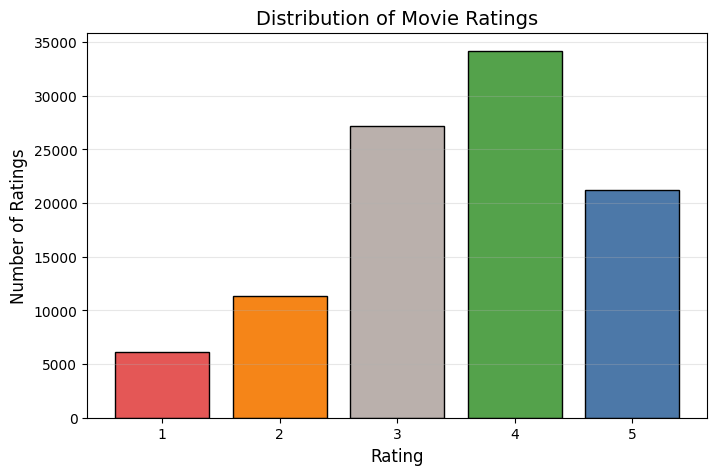

In [9]:
# Visualize rating distribution

plt.figure(figsize=(8, 5))

colors = [red_color, accent_color, gray_color, green_color, main_color]

plt.bar(
    rating_distribution.index,
    rating_distribution.values,
    color=colors,
    edgecolor="black"
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.xticks(rating_distribution.index)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Initial Exploration Summary

The dataset contains 100,000 rating ties between users and movies. This confirms that the dataset is large enough for Project 2. The two node groups are clearly defined: users and movies. Since ratings connect users to movies, and not users to users or movies to movies, the dataset is appropriate for a two-mode network analysis.

The rating distribution also helps us decide how to reduce the network later. Ratings of 4 and 5 can be treated as stronger preference ties, while lower ratings can be considered weaker or less positive connections.


## 4. Build the Two-Mode User–Movie Network

In this section, we convert the ratings dataset into a two-mode network.

The two distinct node groups are:

* **Users**
* **Movies**

An edge is created when a user rates a movie. The rating value is stored as the edge weight. To avoid confusion between user IDs and movie IDs, user nodes are labeled with the prefix `u_`, and movie nodes are labeled with the prefix `m_`.

This network is bipartite because edges only connect users to movies. There are no direct user-to-user edges or movie-to-movie edges in the original network.


In [10]:
# Build the full two-mode/bipartite network

B = nx.Graph()

# Create user and movie nodes with prefixes
user_nodes = ["u_" + str(uid) for uid in ratings["user_id"].unique()]
movie_nodes = ["m_" + str(mid) for mid in ratings["movie_id"].unique()]

# Add nodes with bipartite group labels
B.add_nodes_from(user_nodes, bipartite="users")
B.add_nodes_from(movie_nodes, bipartite="movies")

# Add weighted edges from users to movies
for _, row in ratings.iterrows():
    user_node = "u_" + str(row["user_id"])
    movie_node = "m_" + str(row["movie_id"])
    rating_value = row["rating"]
    
    B.add_edge(user_node, movie_node, weight=rating_value)

print("Total nodes in bipartite network:", B.number_of_nodes())
print("Total edges in bipartite network:", B.number_of_edges())
print("Is the network bipartite?", bipartite.is_bipartite(B))

Total nodes in bipartite network: 2625
Total edges in bipartite network: 100000
Is the network bipartite? True


### 4.1. Network Summary


In [11]:
# Basic bipartite network statistics

num_user_nodes = len(user_nodes)
num_movie_nodes = len(movie_nodes)
num_edges = B.number_of_edges()

bipartite_density = num_edges / (num_user_nodes * num_movie_nodes)

print("Number of user nodes:", num_user_nodes)
print("Number of movie nodes:", num_movie_nodes)
print("Number of edges:", num_edges)
print("Bipartite density:", round(bipartite_density, 4))

Number of user nodes: 943
Number of movie nodes: 1682
Number of edges: 100000
Bipartite density: 0.063


### 4.2. Degree Analysis

In [12]:
# Degree analysis for each node group

user_degree = dict(B.degree(user_nodes))
movie_degree = dict(B.degree(movie_nodes))

top_users = sorted(user_degree.items(), key=lambda x: x[1], reverse=True)[:10]
top_movies = sorted(movie_degree.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 users by number of movie ratings:")
print(top_users)

print("\nTop 10 movies by number of user ratings:")
print(top_movies)

Top 10 users by number of movie ratings:
[('u_405', 737), ('u_655', 685), ('u_13', 636), ('u_450', 540), ('u_276', 518), ('u_416', 493), ('u_537', 490), ('u_303', 484), ('u_234', 480), ('u_393', 448)]

Top 10 movies by number of user ratings:
[('m_50', 583), ('m_258', 509), ('m_100', 508), ('m_181', 507), ('m_294', 485), ('m_286', 481), ('m_288', 478), ('m_1', 452), ('m_300', 431), ('m_121', 429)]


### 4.3. Top Movies

In [13]:
# Convert top movie nodes into a readable table with movie titles

movie_lookup = movies.set_index("movie_id")["title"].to_dict()

top_movie_table = []

for node, degree in top_movies:
    movie_id = int(node.replace("m_", ""))
    
    top_movie_table.append({
        "movie_id": movie_id,
        "title": movie_lookup.get(movie_id),
        "number_of_ratings": degree
    })

top_movie_df = pd.DataFrame(top_movie_table)
top_movie_df

,movie_id,title,number_of_ratings
0,50,Star Wars (1977),583
1,258,Contact (1997),509
2,100,Fargo (1996),508
3,181,Return of the Jedi (1983),507
4,294,Liar Liar (1997),485
5,286,"English Patient, The (1996)",481
6,288,Scream (1996),478
7,1,Toy Story (1995),452
8,300,Air Force One (1997),431
9,121,Independence Day (ID4) (1996),429


### Two-Mode Network Summary

The full network contains users and movies as two separate node groups. Each edge represents a rating from a user to a movie. The bipartite test confirms that this is a valid two-mode network because edges only connect nodes from different groups.

The degree analysis also gives an initial view of activity in the network. Users with high degree values rated many movies, while movies with high degree values received ratings from many users. At this stage, degree measures popularity or activity, but it does not yet separate strong preference ties from weaker or neutral ratings. That reduction is handled later through the island method.


## 5. Island Method Reduction

The full MovieLens network contains all rating ties, including low, neutral, and high ratings. To reduce the network, we use an island-method style approach.

In an island method, weaker ties are removed so that the remaining network shows stronger and more meaningful connections. For this project, the edge weight is the movie rating. Ratings of 4 or 5 are treated as strong preference ties because they represent movies that users liked.

By keeping only ratings of 4 or 5, the network becomes smaller and easier to interpret. The remaining edges represent stronger user–movie relationships.


In [14]:
# Island method reduction:
# Keep only strong ties where rating is 4 or 5

strong_ratings = ratings[ratings["rating"] >= 4].copy()

print("Original number of ratings:", ratings.shape[0])
print("Number of strong ratings:", strong_ratings.shape[0])
print("Ratings removed:", ratings.shape[0] - strong_ratings.shape[0])

reduction_percent = (1 - strong_ratings.shape[0] / ratings.shape[0]) * 100
print("Percent reduction:", round(reduction_percent, 2), "%")

Original number of ratings: 100000
Number of strong ratings: 55375
Ratings removed: 44625
Percent reduction: 44.62 %


### 5.1. Reduced Bipartite Network

In [15]:
# Build reduced bipartite network using only strong ratings

B_strong = nx.Graph()

strong_user_nodes = ["u_" + str(uid) for uid in strong_ratings["user_id"].unique()]
strong_movie_nodes = ["m_" + str(mid) for mid in strong_ratings["movie_id"].unique()]

B_strong.add_nodes_from(strong_user_nodes, bipartite="users")
B_strong.add_nodes_from(strong_movie_nodes, bipartite="movies")

for _, row in strong_ratings.iterrows():
    user_node = "u_" + str(row["user_id"])
    movie_node = "m_" + str(row["movie_id"])
    
    B_strong.add_edge(user_node, movie_node, weight=row["rating"])

print("Original network nodes:", B.number_of_nodes())
print("Original network edges:", B.number_of_edges())

print("\nReduced island network nodes:", B_strong.number_of_nodes())
print("Reduced island network edges:", B_strong.number_of_edges())
print("Is reduced network bipartite?", bipartite.is_bipartite(B_strong))

Original network nodes: 2625
Original network edges: 100000

Reduced island network nodes: 2389
Reduced island network edges: 55375
Is reduced network bipartite? True


### 5.2. Networks Comparison

In [16]:
# Compare full network and reduced network

comparison_df = pd.DataFrame({
    "Network": ["Full Network", "Strong-Tie Island Network"],
    "Nodes": [B.number_of_nodes(), B_strong.number_of_nodes()],
    "Edges": [B.number_of_edges(), B_strong.number_of_edges()]
})

comparison_df

,Network,Nodes,Edges
0,Full Network,2625,100000
1,Strong-Tie Island Network,2389,55375


In [17]:
# Identify connected components, or islands, in the reduced network

components = list(nx.connected_components(B_strong))

component_summary = []

for i, comp in enumerate(components):
    users_in_comp = [n for n in comp if n.startswith("u_")]
    movies_in_comp = [n for n in comp if n.startswith("m_")]
    
    component_summary.append({
        "island_id": i,
        "total_nodes": len(comp),
        "users": len(users_in_comp),
        "movies": len(movies_in_comp)
    })

component_df = pd.DataFrame(component_summary)
component_df = component_df.sort_values(by="total_nodes", ascending=False)

component_df.head(10)

,island_id,total_nodes,users,movies
0,0,2389,942,1447


In [18]:
# Extract the largest island for deeper analysis

largest_component = max(components, key=len)
B_largest = B_strong.subgraph(largest_component).copy()

largest_users = [n for n in B_largest.nodes() if n.startswith("u_")]
largest_movies = [n for n in B_largest.nodes() if n.startswith("m_")]

print("Largest island total nodes:", B_largest.number_of_nodes())
print("Largest island edges:", B_largest.number_of_edges())
print("Users in largest island:", len(largest_users))
print("Movies in largest island:", len(largest_movies))

Largest island total nodes: 2389
Largest island edges: 55375
Users in largest island: 942
Movies in largest island: 1447


### Island Method Interpretation

The island method reduced the original network by removing weaker rating ties and keeping only ratings of 4 or 5. This reduced the number of edges from 100,000 to 55,375, removing 44.62% of the original rating ties.

The reduced network still forms one large connected component. This means that even after removing weaker ratings, most users and movies remain connected through strong preference ties. This is expected in a dense rating dataset like MovieLens, where many users rate popular movies highly.

Because the bipartite strong-tie network remains highly connected, the next step is to create one-mode projections. The user projection will show users connected by shared highly rated movies, while the movie projection will show movies connected by shared users. Applying stronger thresholds to these projected networks will allow us to identify smaller and more interpretable islands.

## 6. One-Mode Projections and Stronger Island Thresholds

After applying the first island-method reduction, the strong-tie bipartite network still remained mostly connected. To identify smaller and more meaningful islands, we create one-mode projections.

A one-mode projection converts the original two-mode network into a network containing only one type of node.

For this project, we create two projections:

* **User projection:** users are connected if they highly rated the same movies.
* **Movie projection:** movies are connected if they were highly rated by the same users.

In these projected networks, edge weights represent shared connections. For example, if two users both gave high ratings to the same 12 movies, the edge weight between those users is 12. If two movies were highly rated by the same 25 users, the edge weight between those movies is 25.

We then apply stronger thresholds to these projected networks to identify more focused islands.


### 6.1. User Projection

In [19]:
# Create user projection from the strong-tie bipartite network
# Users are connected if they highly rated the same movies

strong_users = [n for n in B_strong.nodes() if n.startswith("u_")]

user_projection = bipartite.weighted_projected_graph(B_strong, strong_users)

print("User projection nodes:", user_projection.number_of_nodes())
print("User projection edges:", user_projection.number_of_edges())

User projection nodes: 942
User projection edges: 382442


### 6.2. Movie Projection

In [20]:
# Create movie projection from the strong-tie bipartite network
# Movies are connected if they were highly rated by the same users

strong_movies = [n for n in B_strong.nodes() if n.startswith("m_")]

movie_projection = bipartite.weighted_projected_graph(B_strong, strong_movies)

print("Movie projection nodes:", movie_projection.number_of_nodes())
print("Movie projection edges:", movie_projection.number_of_edges())

Movie projection nodes: 1447
Movie projection edges: 460019


### 6.3. Projection Weights

In [21]:
# Examine edge weight distributions in the projected networks

user_weights = [d["weight"] for _, _, d in user_projection.edges(data=True)]
movie_weights = [d["weight"] for _, _, d in movie_projection.edges(data=True)]

print("User projection edge weight summary:")
print(pd.Series(user_weights).describe())

print("\nMovie projection edge weight summary:")
print(pd.Series(movie_weights).describe())

User projection edge weight summary:
count    382442.000000
mean          9.048261
std          11.804388
min           1.000000
25%           2.000000
50%           5.000000
75%          11.000000
max         179.000000
dtype: float64

Movie projection edge weight summary:
count    460019.000000
mean          6.537806
std          11.839839
min           1.000000
25%           1.000000
50%           2.000000
75%           6.000000
max         349.000000
dtype: float64


### Threshold Selection

The first island-method reduction kept ratings of 4 or 5 and removed weaker ties from the original bipartite network. However, the reduced bipartite network remained mostly connected. To create more interpretable islands, we apply additional thresholds to the one-mode projections.

For the user projection, the threshold requires two users to share at least 10 highly rated movies. For the movie projection, the threshold requires two movies to be highly rated by at least 20 of the same users.

These thresholds are used to focus the analysis on stronger similarity relationships rather than weak overlap.

### 6.4. Island Function 

In [22]:
# Define an island method function for weighted projected networks

def island_method(G, weight_threshold):
    """
    Keep only edges with weight greater than or equal to the selected threshold.
    Remove isolated nodes after filtering.
    """
    H = nx.Graph()
    
    # Keep original node attributes
    H.add_nodes_from(G.nodes(data=True))
    
    # Keep only stronger weighted edges
    for u, v, data in G.edges(data=True):
        if data.get("weight", 1) >= weight_threshold:
            H.add_edge(u, v, weight=data["weight"])
    
    # Remove isolated nodes
    isolated_nodes = list(nx.isolates(H))
    H.remove_nodes_from(isolated_nodes)
    
    return H

In [23]:
# Apply stronger island threshold to user projection
# Users must share at least 10 highly rated movies to remain connected

user_threshold = 10
user_island = island_method(user_projection, user_threshold)

print("Original user projection nodes:", user_projection.number_of_nodes())
print("Original user projection edges:", user_projection.number_of_edges())

print("\nReduced user island nodes:", user_island.number_of_nodes())
print("Reduced user island edges:", user_island.number_of_edges())

Original user projection nodes: 942
Original user projection edges: 382442

Reduced user island nodes: 842
Reduced user island edges: 107440


In [24]:
# Apply stronger island threshold to movie projection
# Movies must share at least 20 users who rated both highly to remain connected

movie_threshold = 20
movie_island = island_method(movie_projection, movie_threshold)

print("Original movie projection nodes:", movie_projection.number_of_nodes())
print("Original movie projection edges:", movie_projection.number_of_edges())

print("\nReduced movie island nodes:", movie_island.number_of_nodes())
print("Reduced movie island edges:", movie_island.number_of_edges())

Original movie projection nodes: 1447
Original movie projection edges: 460019

Reduced movie island nodes: 563
Reduced movie island edges: 35904


### 6.5. Component Summary

In [25]:
# Summarize connected components in user and movie island networks

def component_summary_table(G, node_type_label):
    components = list(nx.connected_components(G))
    
    summary = []
    
    for i, comp in enumerate(components):
        summary.append({
            "island_id": i,
            node_type_label: len(comp),
            "edges": G.subgraph(comp).number_of_edges()
        })
    
    return pd.DataFrame(summary).sort_values(by=node_type_label, ascending=False)

user_island_summary = component_summary_table(user_island, "users")
movie_island_summary = component_summary_table(movie_island, "movies")

print("User island summary:")
display(user_island_summary.head(10))

print("Movie island summary:")
display(movie_island_summary.head(10))

User island summary:


,island_id,users,edges
0,0,842,107440


Movie island summary:


,island_id,movies,edges
0,0,563,35904


### Section 6 Interpretation

The one-mode projection results show that the original strong-tie bipartite network was still very dense. To make the network more interpretable, additional island thresholds were applied to the user and movie projections.

In the user projection, the original network contained 942 users and 382,442 edges. After requiring users to share at least 10 highly rated movies, the reduced user island contained 842 users and 107,440 edges. This removed a large number of weaker user-user similarity ties while keeping the main group of users with strong shared preferences.

In the movie projection, the original network contained 1,447 movies and 460,019 edges. After requiring movies to share at least 20 users who rated both highly, the reduced movie island contained 563 movies and 35,904 edges. This was a much stronger reduction and removed most weak movie-movie similarity ties.

The component summary shows one major user island and one major movie island. This means that even after thresholding, the strongest users and movies remain connected through shared preference patterns. Instead of many small disconnected islands, the analysis identifies a large strong-preference core for users and a smaller strong-preference core for movies.

## 7. User Group Analysis

In this section, we analyze the users who remain in the reduced user island network. The reduced user island contains users who share at least 10 highly rated movies with another user. This means these users are not only active raters, but they also have stronger preference overlap with other users.

To infer patterns about the user group, we examine user demographics such as age, gender, and occupation. We also identify the most connected users in the reduced user island network.


### 7.1. Extract User IDs from Reduced User Island


In [26]:
# Extract user IDs from the reduced user island network

user_island_ids = [
    int(node.replace("u_", ""))
    for node in user_island.nodes()
]

user_island_data = users[users["user_id"].isin(user_island_ids)].copy()

print("Number of users in full user dataset:", users.shape[0])
print("Number of users in reduced user island:", user_island_data.shape[0])

user_island_data.head()

Number of users in full user dataset: 943
Number of users in reduced user island: 842


,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
3,4,24,M,technician,43537
4,5,33,F,other,15213
5,6,42,M,executive,98101


### 7.2. Merge with User Demographics


In [27]:
# Summary statistics for users in the reduced user island

user_age_summary = user_island_data["age"].describe()

print("Age summary for users in the reduced user island:")
print(user_age_summary)

print("\nGender counts:")
print(user_island_data["gender"].value_counts())

print("\nTop 10 occupations:")
print(user_island_data["occupation"].value_counts().head(10))

Age summary for users in the reduced user island:
count    842.000000
mean      33.893112
std       12.072826
min        7.000000
25%       25.000000
50%       31.000000
75%       42.000000
max       73.000000
Name: age, dtype: float64

Gender counts:
M    615
F    227
Name: gender, dtype: int64

Top 10 occupations:
student          180
other             92
educator          83
administrator     65
programmer        64
engineer          63
librarian         44
writer            43
executive         29
scientist         27
Name: occupation, dtype: int64


In [28]:
# Compare full user group with reduced user island group

full_user_summary = {
    "group": "All Users",
    "num_users": users.shape[0],
    "avg_age": round(users["age"].mean(), 2),
    "median_age": users["age"].median(),
    "male_count": users[users["gender"] == "M"].shape[0],
    "female_count": users[users["gender"] == "F"].shape[0]
}

island_user_summary = {
    "group": "Reduced User Island",
    "num_users": user_island_data.shape[0],
    "avg_age": round(user_island_data["age"].mean(), 2),
    "median_age": user_island_data["age"].median(),
    "male_count": user_island_data[user_island_data["gender"] == "M"].shape[0],
    "female_count": user_island_data[user_island_data["gender"] == "F"].shape[0]
}

user_comparison_df = pd.DataFrame([full_user_summary, island_user_summary])

user_comparison_df

,group,num_users,avg_age,median_age,male_count,female_count
0,All Users,943,34.05,31.0,670,273
1,Reduced User Island,842,33.89,31.0,615,227


### 7.3. Analyze Age, Gender, and Occupation


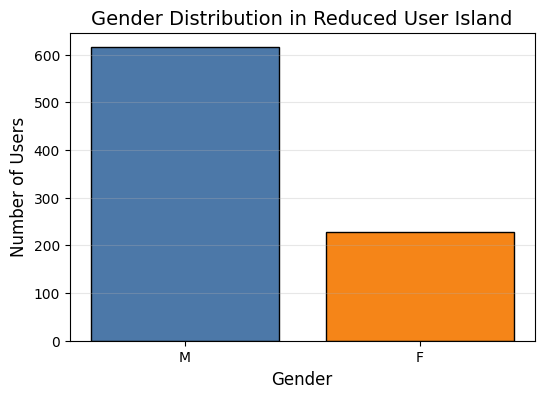

In [29]:
# Visualize gender distribution in the reduced user island

gender_counts = user_island_data["gender"].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(
    gender_counts.index,
    gender_counts.values,
    color=[main_color, accent_color],
    edgecolor="black"
)

plt.title("Gender Distribution in Reduced User Island")
plt.xlabel("Gender")
plt.ylabel("Number of Users")
plt.grid(axis="y", alpha=0.3)

plt.show()

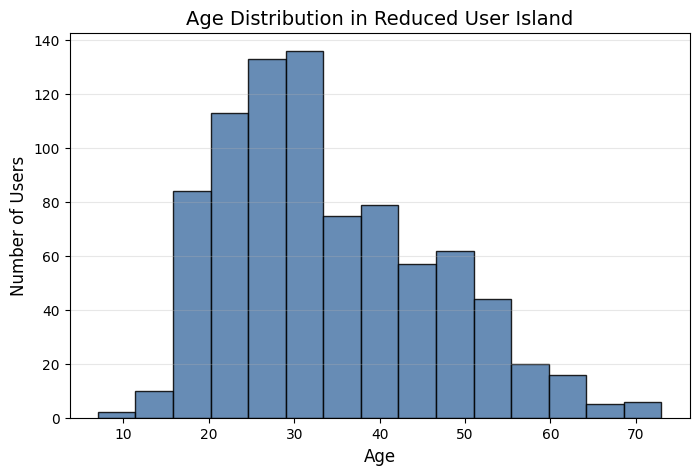

In [30]:
# Visualize age distribution in the reduced user island

plt.figure(figsize=(8, 5))

plt.hist(
    user_island_data["age"],
    bins=15,
    color=main_color,
    edgecolor="black",
    alpha=0.85
)

plt.title("Age Distribution in Reduced User Island")
plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [31]:
# Top occupations in the reduced user island

top_occupations = user_island_data["occupation"].value_counts().head(10)

top_occupations

student          180
other             92
educator          83
administrator     65
programmer        64
engineer          63
librarian         44
writer            43
executive         29
scientist         27
Name: occupation, dtype: int64

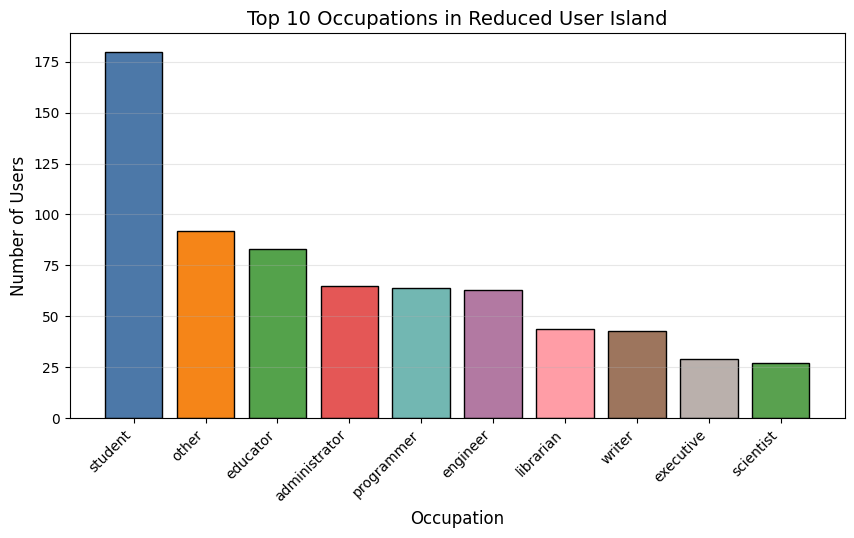

In [32]:
# Visualize top occupations in the reduced user island

plt.figure(figsize=(10, 5))

plt.bar(
    top_occupations.index,
    top_occupations.values,
    color=palette[:len(top_occupations)],
    edgecolor="black"
)

plt.title("Top 10 Occupations in Reduced User Island")
plt.xlabel("Occupation")
plt.ylabel("Number of Users")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [33]:
# Identify most connected users in the reduced user island
# Degree here means number of other users with similar strong movie preferences

user_island_degree = dict(user_island.degree())

top_user_island_degree = sorted(
    user_island_degree.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

top_user_island_table = []

for node, degree in top_user_island_degree:
    user_id = int(node.replace("u_", ""))
    user_info = users[users["user_id"] == user_id].iloc[0]
    
    top_user_island_table.append({
        "user_id": user_id,
        "similar_user_connections": degree,
        "age": user_info["age"],
        "gender": user_info["gender"],
        "occupation": user_info["occupation"]
    })

top_user_island_df = pd.DataFrame(top_user_island_table)

top_user_island_df

,user_id,similar_user_connections,age,gender,occupation
0,416,762,20,F,student
1,592,745,18,M,student
2,276,730,21,M,student
3,450,727,35,F,educator
4,758,701,27,M,student
5,130,667,20,M,none
6,303,662,19,M,student
7,474,658,51,M,executive
8,864,658,27,M,programmer
9,551,657,25,M,programmer


### User Group Interpretation

The reduced user island contains 842 users out of the 943 users in the full dataset. This means that about 89% of users remain in the strong user island after applying the projection threshold. These users are connected because they share at least 10 highly rated movies with another user.

The age profile of the reduced user island is very similar to the full user dataset. The average age of all users is 34.05, while the average age of users in the reduced island is 33.89. The median age is 31 in both groups. This suggests that the island reduction did not strongly change the age composition of the user group.

The gender distribution in the reduced user island is also similar to the full dataset. The reduced island contains 615 male users and 227 female users. Since the full dataset is also male-heavy, this pattern should be interpreted as a reflection of the original dataset rather than a result caused only by the island method.

Occupation gives more useful insight into the user group. The most common occupation in the reduced user island is student, with 180 users. Other common occupations include other, educator, administrator, programmer, and engineer. This suggests that the strongest user preference core is heavily represented by students and professional or technical users.

The most connected users in the reduced user island have hundreds of similar-user connections. These users are connected to many other users through shared highly rated movies. Several of the most connected users are students, programmers, or educators, which supports the idea that these groups are strongly represented in the shared-preference core.

Overall, the user group analysis shows that the reduced user island captures a large core of users with overlapping movie preferences. The island does not differ strongly from the full dataset by age, but it highlights a strong preference network where students and professional or technical occupations are highly visible.


## 8. Movie Group Analysis

In this section, we analyze the movies that remain in the reduced movie island network. The reduced movie island contains movies that share at least 20 users who rated both movies highly. This means the movies in this island are not just individually popular; they are connected because they are liked by overlapping groups of users.

To infer patterns about the movie group, we examine movie genres, identify the most common genres in the reduced movie island, and identify the most connected movies in the reduced movie network.


In [34]:
# Extract movie IDs from the reduced movie island network

movie_island_ids = [
    int(node.replace("m_", ""))
    for node in movie_island.nodes()
]

movie_island_data = movies[movies["movie_id"].isin(movie_island_ids)].copy()

print("Number of movies in full movie dataset:", movies.shape[0])
print("Number of movies in reduced movie island:", movie_island_data.shape[0])

movie_island_data.head()

Number of movies in full movie dataset: 1682
Number of movies in reduced movie island: 563


,movie_id,title,release_date,video_release_date,imdb_url,unknown,Action,Adventure,Animation,Children,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


### 8.1 Genre Distribution in the Reduced Movie Island

The MovieLens movie file includes genre indicator columns. A movie can belong to more than one genre, so genre counts represent the number of genre labels, not necessarily the number of unique movies.

In [35]:
# Count genres in the reduced movie island

movie_island_genre_counts = movie_island_data[genre_cols].sum().sort_values(ascending=False)

movie_island_genre_counts

Drama          251
Comedy         158
Thriller       116
Action         116
Romance        112
Adventure       65
Sci-Fi          57
War             46
Crime           44
Children        36
Mystery         33
Musical         28
Horror          27
Animation       24
Film-Noir       14
Western         12
Fantasy          7
Documentary      6
unknown          0
dtype: int64

In [36]:
# Calculate percentage of movies retained in the reduced movie island

movie_retention_percent = movie_island_data.shape[0] / movies.shape[0] * 100
movie_removed_percent = 100 - movie_retention_percent

print("Percent of movies retained:", round(movie_retention_percent, 2), "%")
print("Percent of movies removed:", round(movie_removed_percent, 2), "%")

Percent of movies retained: 33.47 %
Percent of movies removed: 66.53 %


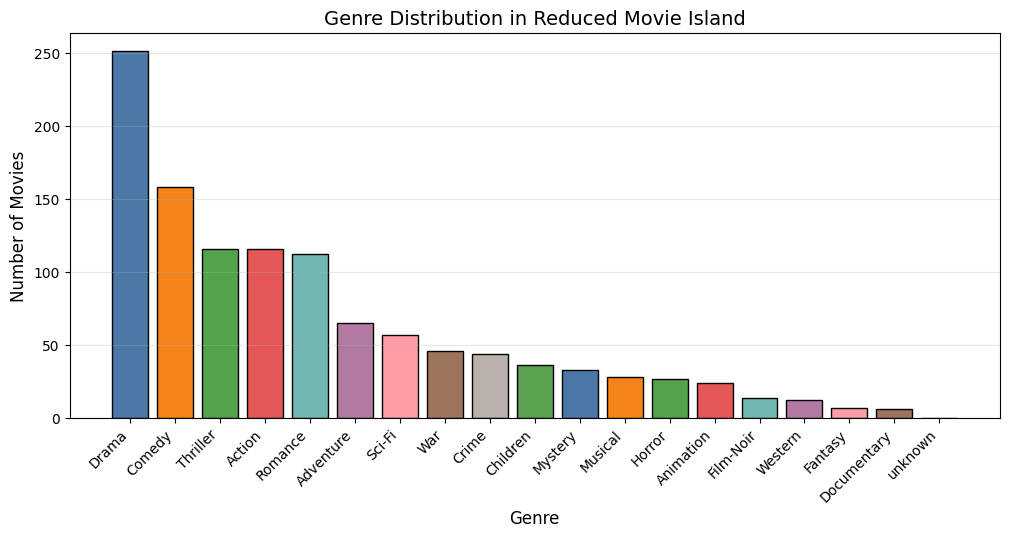

In [37]:
# Visualize genre distribution in the reduced movie island

plt.figure(figsize=(12, 5))

genre_colors = palette * 3

plt.bar(
    movie_island_genre_counts.index,
    movie_island_genre_counts.values,
    color=genre_colors[:len(movie_island_genre_counts)],
    edgecolor="black"
)

plt.title("Genre Distribution in Reduced Movie Island")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.show()

### 8.2 Compare Full Movie Dataset with Reduced Movie Island

Next, we compare the genre distribution of the full movie dataset with the reduced movie island. This helps show whether the island method kept certain types of movies more strongly than others.

In [38]:
# Compare genre counts between all movies and reduced movie island

full_movie_genre_counts = movies[genre_cols].sum().sort_values(ascending=False)

genre_comparison_df = pd.DataFrame({
    "genre": genre_cols,
    "all_movies": [full_movie_genre_counts.get(g, 0) for g in genre_cols],
    "reduced_movie_island": [movie_island_genre_counts.get(g, 0) for g in genre_cols]
})

genre_comparison_df["percent_of_all_movies"] = round(
    genre_comparison_df["all_movies"] / movies.shape[0] * 100, 2
)

genre_comparison_df["percent_of_reduced_island"] = round(
    genre_comparison_df["reduced_movie_island"] / movie_island_data.shape[0] * 100, 2
)

genre_comparison_df.sort_values(
    by="reduced_movie_island",
    ascending=False
)

,genre,all_movies,reduced_movie_island,percent_of_all_movies,percent_of_reduced_island
8,Drama,725,251,43.10,44.58
5,Comedy,505,158,30.02,28.06
16,Thriller,251,116,14.92,20.60
1,Action,251,116,14.92,20.60
14,Romance,247,112,14.68,19.89
2,Adventure,135,65,8.03,11.55
15,Sci-Fi,101,57,6.00,10.12
17,War,71,46,4.22,8.17
6,Crime,109,44,6.48,7.82
4,Children,122,36,7.25,6.39


### 8.3 Most Connected Movies in the Reduced Movie Island

In the reduced movie island, degree represents how many other movies a movie is connected to through shared users. A highly connected movie is one that shares strong audience overlap with many other movies.

In [39]:
# Identify most connected movies in the reduced movie island

movie_island_degree = dict(movie_island.degree())

top_movie_island_degree = sorted(
    movie_island_degree.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

def get_movie_genres(movie_row):
    selected_genres = [
        genre for genre in genre_cols
        if movie_row[genre] == 1
    ]
    return ", ".join(selected_genres)

top_movie_island_table = []

for node, degree in top_movie_island_degree:
    movie_id = int(node.replace("m_", ""))
    movie_info = movies[movies["movie_id"] == movie_id].iloc[0]
    
    top_movie_island_table.append({
        "movie_id": movie_id,
        "title": movie_info["title"],
        "movie_connections": degree,
        "genres": get_movie_genres(movie_info)
    })

top_movie_island_df = pd.DataFrame(top_movie_island_table)

top_movie_island_df

,movie_id,title,movie_connections,genres
0,50,Star Wars (1977),527,"Action, Adventure, Romance, Sci-Fi, War"
1,100,Fargo (1996),479,"Crime, Drama, Thriller"
2,98,"Silence of the Lambs, The (1991)",473,"Drama, Thriller"
3,181,Return of the Jedi (1983),472,"Action, Adventure, Romance, Sci-Fi, War"
4,174,Raiders of the Lost Ark (1981),472,"Action, Adventure"
5,56,Pulp Fiction (1994),446,"Crime, Drama"
6,127,"Godfather, The (1972)",439,"Action, Crime, Drama"
7,172,"Empire Strikes Back, The (1980)",437,"Action, Adventure, Drama, Romance, Sci-Fi, War"
8,79,"Fugitive, The (1993)",431,"Action, Thriller"
9,64,"Shawshank Redemption, The (1994)",426,Drama


In [40]:
# Identify movies with the most high ratings in the strong-tie bipartite network

strong_movie_rating_counts = strong_ratings["movie_id"].value_counts().head(10)

top_strong_movies = []

for movie_id, count in strong_movie_rating_counts.items():
    movie_info = movies[movies["movie_id"] == movie_id].iloc[0]
    
    top_strong_movies.append({
        "movie_id": movie_id,
        "title": movie_info["title"],
        "high_rating_count": count,
        "genres": get_movie_genres(movie_info)
    })

top_strong_movies_df = pd.DataFrame(top_strong_movies)

top_strong_movies_df

,movie_id,title,high_rating_count,genres
0,50,Star Wars (1977),501,"Action, Adventure, Romance, Sci-Fi, War"
1,100,Fargo (1996),406,"Crime, Drama, Thriller"
2,181,Return of the Jedi (1983),379,"Action, Adventure, Romance, Sci-Fi, War"
3,127,"Godfather, The (1972)",351,"Action, Crime, Drama"
4,174,Raiders of the Lost Ark (1981),348,"Action, Adventure"
5,98,"Silence of the Lambs, The (1991)",344,"Drama, Thriller"
6,258,Contact (1997),344,"Drama, Sci-Fi"
7,1,Toy Story (1995),321,"Animation, Children, Comedy"
8,286,"English Patient, The (1996)",298,"Drama, Romance, War"
9,56,Pulp Fiction (1994),294,"Crime, Drama"


### Movie Group Interpretation

The reduced movie island contains 563 movies out of the 1,682 movies in the full MovieLens movie dataset. This means the island method reduced the movie group to about one-third of the original movie set. These remaining movies are connected because they share at least 20 users who rated both movies highly.

The genre analysis shows that the reduced movie island is dominated by mainstream and broadly popular genres. The most common genre is Drama, with 251 movies, followed by Comedy with 158 movies. Thriller and Action each appear 116 times, and Romance appears 112 times. This suggests that the strongest shared-audience core is not limited to one genre. Instead, it contains a mix of drama, comedy, action, thriller, and romance films.

The genre comparison also shows that some genres become more visible inside the reduced island. For example, Action and Thriller each represent 20.60% of the reduced island, compared with 14.92% of the full movie dataset. Sci-Fi and War also appear more strongly in the reduced island than in the full dataset. This suggests that users with overlapping high-rating behavior are especially connected around popular action, thriller, science-fiction, and war-related films.

The most connected movies in the reduced movie island include Star Wars (1977), Fargo (1996), The Silence of the Lambs (1991), Return of the Jedi (1983), and Raiders of the Lost Ark (1981). These movies are important because they share strong audience overlap with many other movies. Star Wars (1977) is especially central, with 527 movie connections, and it also has the highest number of strong ratings.

Overall, the movie group analysis shows that the island method identifies a smaller core of movies with strong shared-audience patterns. The reduced island is centered around widely liked and culturally popular movies, especially drama, comedy, action, thriller, science-fiction, and adventure titles.


## 9. Network Visualizations

The reduced user and movie island networks are still large and dense, so plotting every node and edge would be difficult to interpret. Instead, this section visualizes smaller subgraphs based on the most connected nodes.

For the user island, we visualize the most connected users in the reduced user projection. These users share strong movie preferences with many other users.

For the movie island, we visualize the most connected movies in the reduced movie projection. These movies share strong audience overlap with many other movies.


In [41]:
# Helper function to create a smaller visualization subgraph

def top_degree_subgraph(G, top_n=75):
    degree_dict = dict(G.degree())
    
    top_nodes = sorted(
        degree_dict,
        key=degree_dict.get,
        reverse=True
    )[:top_n]
    
    return G.subgraph(top_nodes).copy()

### 9.1 Reduced User Island Visualization

This visualization shows the most connected users in the reduced user island. Each node represents a user, and each edge represents a strong shared-preference relationship based on highly rated movies.

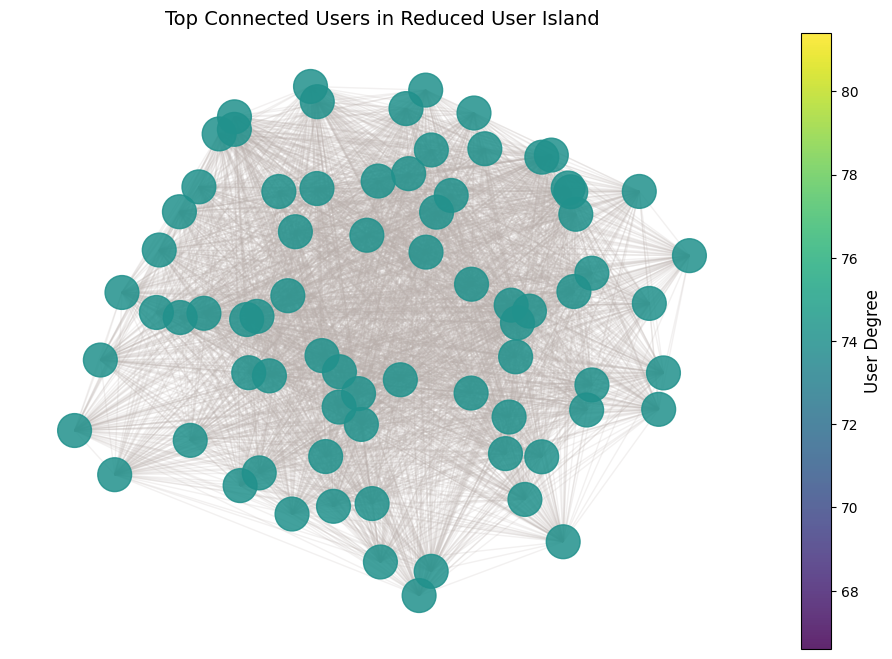

In [42]:
# Visualize top users in the reduced user island

user_viz = top_degree_subgraph(user_island, top_n=75)

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(user_viz, seed=42)

degrees = dict(user_viz.degree())

node_sizes = [
    degrees[node] * 8
    for node in user_viz.nodes()
]

node_colors = [
    degrees[node]
    for node in user_viz.nodes()
]

nodes = nx.draw_networkx_nodes(
    user_viz,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.viridis,
    alpha=0.85
)

nx.draw_networkx_edges(
    user_viz,
    pos,
    edge_color=gray_color,
    alpha=0.18
)

plt.colorbar(nodes, label="User Degree")
plt.title("Top Connected Users in Reduced User Island")
plt.axis("off")
plt.show()

### 9.2 Reduced Movie Island Visualization

This visualization shows the most connected movies in the reduced movie island. Each node represents a movie, and each edge represents strong audience overlap between two movies.

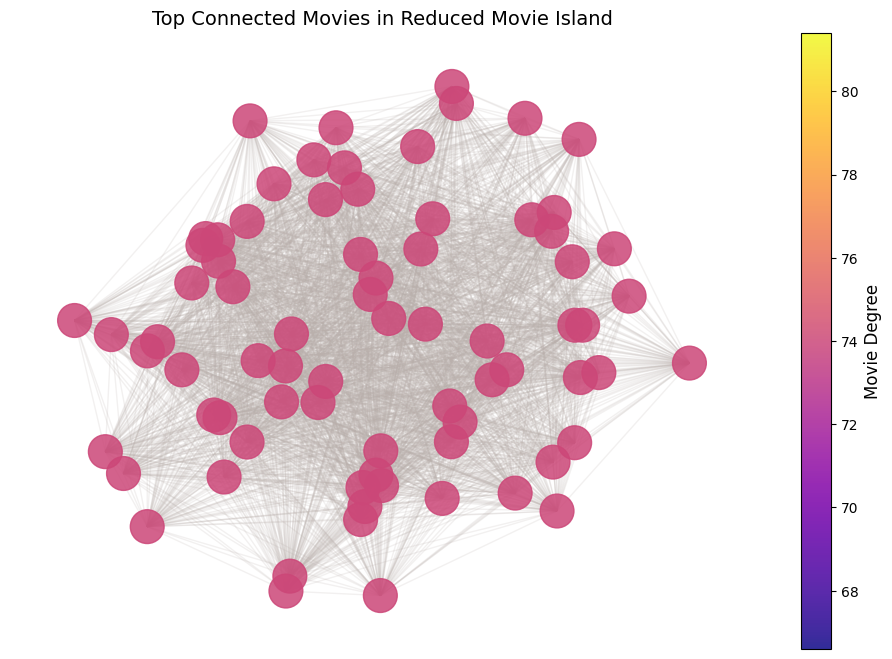

In [43]:
# Visualize top movies in the reduced movie island

movie_viz = top_degree_subgraph(movie_island, top_n=75)

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(movie_viz, seed=42)

degrees = dict(movie_viz.degree())

node_sizes = [
    degrees[node] * 8
    for node in movie_viz.nodes()
]

node_colors = [
    degrees[node]
    for node in movie_viz.nodes()
]

nodes = nx.draw_networkx_nodes(
    movie_viz,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.plasma,
    alpha=0.85
)

nx.draw_networkx_edges(
    movie_viz,
    pos,
    edge_color=gray_color,
    alpha=0.18
)

plt.colorbar(nodes, label="Movie Degree")
plt.title("Top Connected Movies in Reduced Movie Island")
plt.axis("off")
plt.show()

### 9.3 Labeled Movie Network Visualization

The previous graph shows the structure of the movie island, but it does not display movie titles. To make the movie network easier to interpret, the next visualization labels only the most connected movies. This avoids clutter while still showing the most central titles.

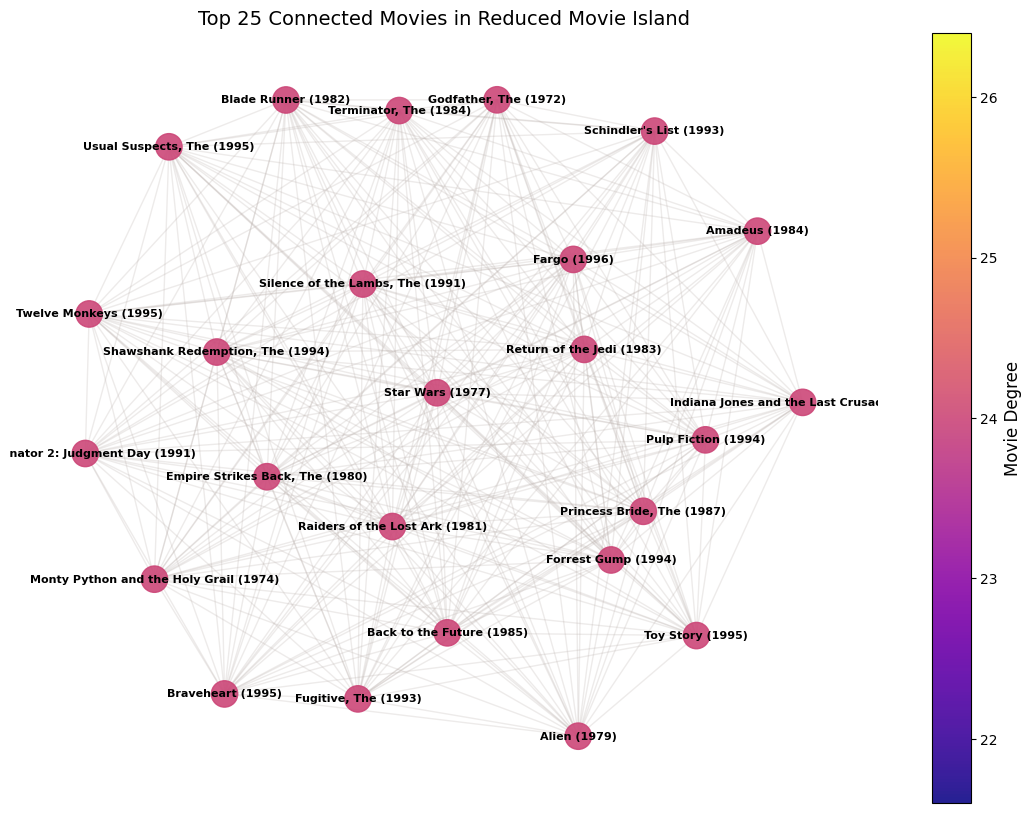

In [44]:
# Create a smaller labeled movie network for readability

movie_viz_labeled = top_degree_subgraph(movie_island, top_n=25)

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(movie_viz_labeled, seed=42)

degrees = dict(movie_viz_labeled.degree())

node_sizes = [
    degrees[node] * 15
    for node in movie_viz_labeled.nodes()
]

node_colors = [
    degrees[node]
    for node in movie_viz_labeled.nodes()
]

nodes = nx.draw_networkx_nodes(
    movie_viz_labeled,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.plasma,
    alpha=0.9
)

nx.draw_networkx_edges(
    movie_viz_labeled,
    pos,
    edge_color=gray_color,
    alpha=0.25
)

movie_labels = {}

for node in movie_viz_labeled.nodes():
    movie_id = int(node.replace("m_", ""))
    title = movies.loc[movies["movie_id"] == movie_id, "title"].values[0]
    movie_labels[node] = title

nx.draw_networkx_labels(
    movie_viz_labeled,
    pos,
    labels=movie_labels,
    font_size=8,
    font_weight="bold"
)

plt.colorbar(nodes, label="Movie Degree")
plt.title("Top 25 Connected Movies in Reduced Movie Island")
plt.axis("off")
plt.show()

### 9.4 Network Reduction Summary Visualization

The final visualization compares the original projected networks with the reduced island networks. This helps show how much the island thresholds reduced the user and movie similarity networks.

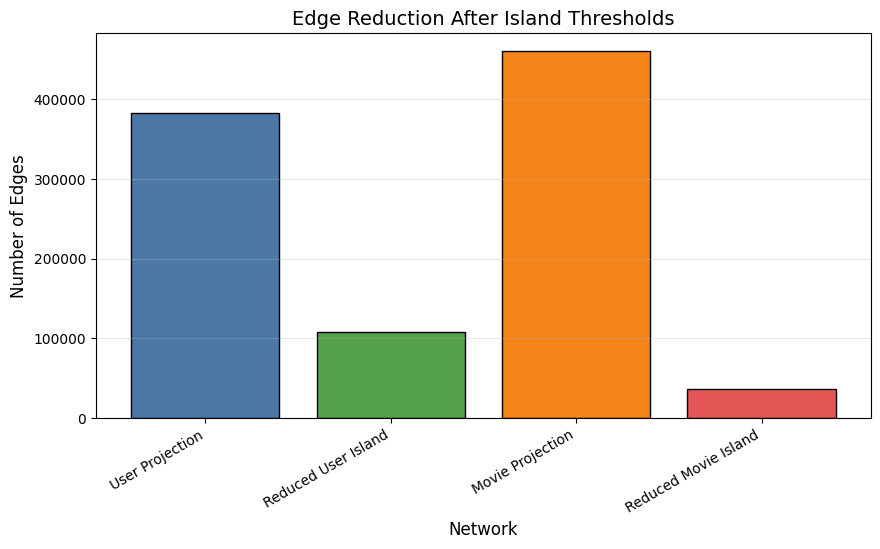

In [45]:
# Visualize edge reduction from projections to island networks

edge_reduction = pd.DataFrame({
    "Network": [
        "User Projection",
        "Reduced User Island",
        "Movie Projection",
        "Reduced Movie Island"
    ],
    "Edges": [
        user_projection.number_of_edges(),
        user_island.number_of_edges(),
        movie_projection.number_of_edges(),
        movie_island.number_of_edges()
    ]
})

plt.figure(figsize=(10, 5))

plt.bar(
    edge_reduction["Network"],
    edge_reduction["Edges"],
    color=[main_color, green_color, accent_color, red_color],
    edgecolor="black"
)

plt.title("Edge Reduction After Island Thresholds")
plt.xlabel("Network")
plt.ylabel("Number of Edges")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Visualization Interpretation

The visualizations show that the reduced island networks still contain dense cores of highly connected users and movies. Because the full reduced networks are large, the graphs focus on the most connected nodes to make the structure easier to interpret.

The user visualization shows a dense group of users with strong shared movie preferences. These users are connected because they share many highly rated movies with one another.

The movie visualization shows a dense group of movies with strong audience overlap. The labeled movie graph makes it easier to see central titles in the reduced movie island. Movies such as widely popular action, drama, thriller, science-fiction, and adventure titles appear near the center of the shared-audience network.

The edge reduction summary confirms that the island thresholds substantially reduced the projected networks. This supports the purpose of the island method: reducing a large network to a smaller and more interpretable core of stronger relationships.


## 10. Overall Findings and Answer to Research Question

The research question for this project was:

**How can an island-method reduction of a two-mode user–movie rating network reveal stronger preference-based clusters among users and movies?**

The analysis shows that the island-method approach can reduce a large two-mode network into a smaller and more interpretable structure by removing weaker ties and keeping stronger preference relationships.

In the original bipartite network, users were connected to movies through all ratings. This produced a large network with 2,625 nodes and 100,000 edges. After keeping only ratings of 4 or 5, the strong-tie island network contained 2,389 nodes and 55,375 edges. This removed 44.62% of the original rating ties.

The strong-tie bipartite network still remained mostly connected, so one-mode projections were created for deeper analysis. In the user projection, users were connected if they highly rated the same movies. After applying a threshold of at least 10 shared highly rated movies, the reduced user island contained 842 users and 107,440 edges. This revealed a strong user preference core.

In the movie projection, movies were connected if they were highly rated by the same users. After applying a threshold of at least 20 shared high-rating users, the reduced movie island contained 563 movies and 35,904 edges. This created a much smaller movie network focused on strong audience overlap.

For the user group, the reduced island showed that many users remained connected through shared movie preferences. The user island did not differ strongly from the full dataset by age, but students and professional or technical occupations were highly visible in the shared-preference core.

For the movie group, the reduced island showed that the strongest shared-audience core was centered around mainstream and widely liked genres, especially Drama, Comedy, Action, Thriller, Romance, Sci-Fi, and Adventure. Highly connected movies such as Star Wars (1977), Fargo (1996), The Silence of the Lambs (1991), Return of the Jedi (1983), and Raiders of the Lost Ark (1981) acted as central titles in the movie preference network.

Overall, the island method helped reduce noise in the original network and highlight stronger patterns of user similarity and movie audience overlap.


In [46]:
# Final summary of main network reductions

final_summary = pd.DataFrame({
    "Network Stage": [
        "Original Bipartite Network",
        "Strong-Tie Bipartite Network",
        "User Projection",
        "Reduced User Island",
        "Movie Projection",
        "Reduced Movie Island"
    ],
    "Nodes": [
        B.number_of_nodes(),
        B_strong.number_of_nodes(),
        user_projection.number_of_nodes(),
        user_island.number_of_nodes(),
        movie_projection.number_of_nodes(),
        movie_island.number_of_nodes()
    ],
    "Edges": [
        B.number_of_edges(),
        B_strong.number_of_edges(),
        user_projection.number_of_edges(),
        user_island.number_of_edges(),
        movie_projection.number_of_edges(),
        movie_island.number_of_edges()
    ]
})

final_summary

,Network Stage,Nodes,Edges
0,Original Bipartite Network,2625,100000
1,Strong-Tie Bipartite Network,2389,55375
2,User Projection,942,382442
3,Reduced User Island,842,107440
4,Movie Projection,1447,460019
5,Reduced Movie Island,563,35904


In [47]:
# Calculate key reduction percentages

bipartite_edge_reduction = (
    1 - B_strong.number_of_edges() / B.number_of_edges()
) * 100

user_projection_edge_reduction = (
    1 - user_island.number_of_edges() / user_projection.number_of_edges()
) * 100

movie_projection_edge_reduction = (
    1 - movie_island.number_of_edges() / movie_projection.number_of_edges()
) * 100

print("Bipartite edge reduction:", round(bipartite_edge_reduction, 2), "%")
print("User projection edge reduction:", round(user_projection_edge_reduction, 2), "%")
print("Movie projection edge reduction:", round(movie_projection_edge_reduction, 2), "%")

Bipartite edge reduction: 44.62 %
User projection edge reduction: 71.91 %
Movie projection edge reduction: 92.2 %


### Summary of Reduction Results

The reduction results show that the island method was effective at reducing the network at multiple levels.

First, filtering the original bipartite network to keep only ratings of 4 or 5 removed 44.62% of all rating ties. This created a strong-tie user–movie network.

Second, applying an island threshold to the user projection removed weaker user-user similarity ties. The user projection edge count dropped from 382,442 to 107,440 edges, which shows that many weak user similarity relationships were removed.

Third, applying an island threshold to the movie projection produced the strongest reduction. The movie projection edge count dropped from 460,019 to 35,904 edges. This means the movie island network retained only the strongest shared-audience relationships.

These results support the research question by showing that island-method reduction can reveal stronger preference-based structures in a large two-mode network.


## 11. Conclusion

This project analyzed the MovieLens 100K dataset as a two-mode network. The two distinct node groups were users and movies, and the ties between them represented user ratings of movies. This structure made the dataset appropriate for bipartite network analysis because users were connected to movies, but not directly to other users or other movies in the original network.

The first reduction step used an island-method style approach by keeping only ratings of 4 or 5. These ratings were treated as strong preference ties. This reduced the original bipartite network from 100,000 edges to 55,375 edges, removing 44.62% of the original ties.

Because the strong-tie bipartite network still remained highly connected, one-mode projections were created for users and movies. The user projection connected users who highly rated the same movies. After applying a threshold of at least 10 shared highly rated movies, the reduced user island contained 842 users and 107,440 edges. This helped identify a strong core of users with overlapping movie preferences.

The movie projection connected movies that were highly rated by the same users. After applying a threshold of at least 20 shared high-rating users, the reduced movie island contained 563 movies and 35,904 edges. This reduction was especially useful because it highlighted a smaller group of movies with strong audience overlap.

The user group analysis showed that the reduced user island was similar to the full dataset by age and gender, but students and professional or technical occupations were highly visible in the shared-preference core. The movie group analysis showed that the reduced movie island was centered around popular and broadly liked genres, especially Drama, Comedy, Action, Thriller, Romance, Sci-Fi, and Adventure.

Overall, the island method helped reduce the original large network into stronger and more interpretable preference structures. The analysis showed that two-mode network methods can reveal meaningful patterns about both groups in the dataset: users with similar preferences and movies with overlapping audiences.


## 12. References and Video Presentation

### References

GroupLens Research. MovieLens 100K Dataset.
https://grouplens.org/datasets/movielens/100k/

GroupLens Research. MovieLens 100K README File.
https://files.grouplens.org/datasets/movielens/ml-100k-README.txt

NetworkX Documentation. Bipartite Algorithms.
https://networkx.org/documentation/stable/reference/algorithms/bipartite.html

NetworkX Documentation. Weighted Projected Graph.
https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.bipartite.projection.weighted_projected_graph.html

Tsvetovat, M., & Kouznetsov, A. Social Network Analysis for Startups: Finding Connections on the Social Web. O’Reilly Media.
Island method concept discussed in Chapter 4 course material.

### Video Presentation

A short video presentation explaining this notebook and the Project 2 analysis will be added after recording.

**Video Link:** To be added.
